In [3]:
!pip install scikit-fuzzy

from skfuzzy import control
import numpy as np

#entradas
distancia = control.Antecedent(np.arange(0, 100.1, 0.1), 'distancia')
velocidade_atual = control.Antecedent(np.arange(0, 100.1, 0.1), 'velocidade_atual')

#saida
pressao_no_freio = control.Consequent(np.arange(0, 100.1, 0.1), 'pressao_no_freio')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 3.8 MB/s eta 0:00:00


In [5]:
from skfuzzy import gaussmf, zmf, smf, trimf # mf - membership function = função de pertinência

distancia['curta'] = trimf(distancia.universe, [0, 0, 40])
distancia['media'] = trimf(distancia.universe, [20, 50, 80])
distancia['longa'] = trimf(distancia.universe, [60, 100, 100])

velocidade_atual['lenta'] = trimf(velocidade_atual.universe, [0, 0, 40])
velocidade_atual['moderada'] = trimf(velocidade_atual.universe, [20, 50, 80])
velocidade_atual['rapida'] = trimf(velocidade_atual.universe, [60, 100, 100])

pressao_no_freio['suave'] = trimf(pressao_no_freio.universe, [0, 0, 40])
pressao_no_freio['media'] = trimf(pressao_no_freio.universe, [20, 50, 80])
pressao_no_freio['forte'] = trimf(pressao_no_freio.universe, [60, 100, 100])

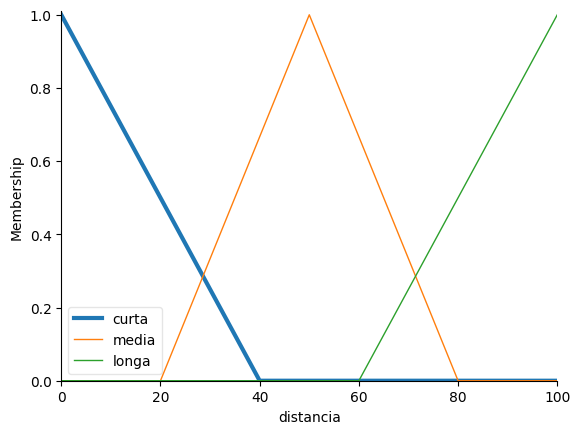

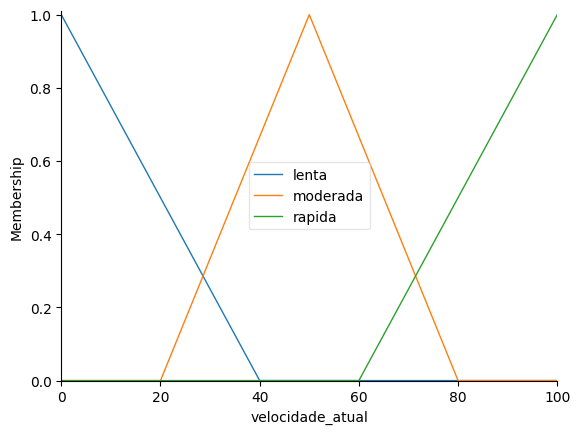

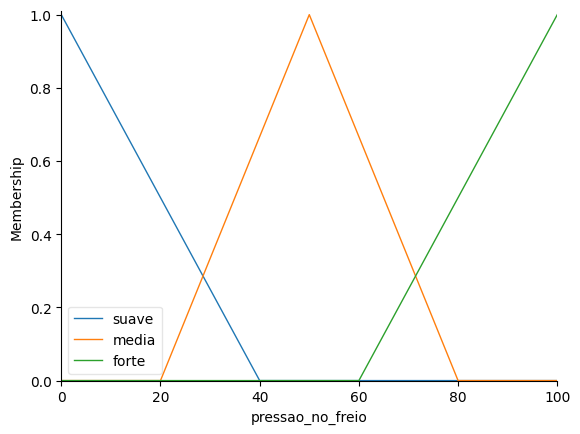

In [8]:
import matplotlib.pyplot as plt
distancia['curta'].view()
velocidade_atual.view()
pressao_no_freio.view()

In [49]:
regra1 = control.Rule(distancia['curta'] | velocidade_atual['rapida'], pressao_no_freio['forte'])
regra2 = control.Rule(distancia['media'] &  velocidade_atual['moderada'], pressao_no_freio['media'])
regra3 = control.Rule(distancia['longa'] | velocidade_atual['lenta'], pressao_no_freio['suave'])



regras = control.ControlSystem([regra1, regra2, regra3])
freio_controle = control.ControlSystemSimulation(regras)

freio_controle.input['distancia'] = 1
freio_controle.input['velocidade_atual'] = 100

freio_controle.compute()

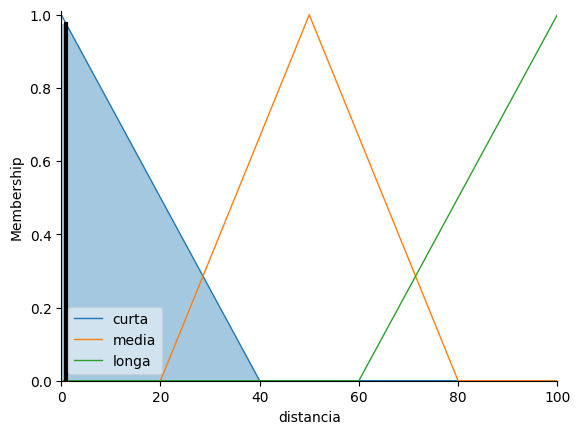

In [50]:
distancia.view(sim=freio_controle)

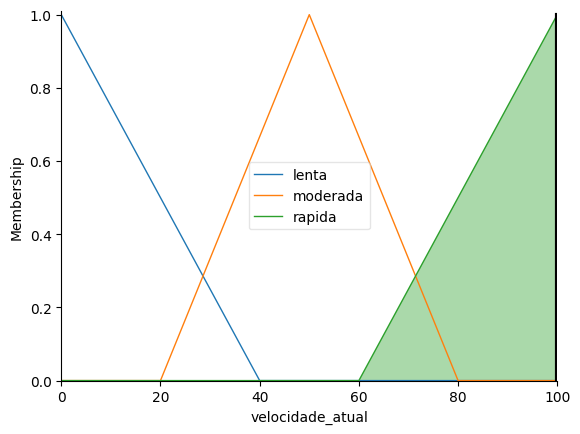

In [51]:
velocidade_atual.view(sim=freio_controle)

86.66666666666667


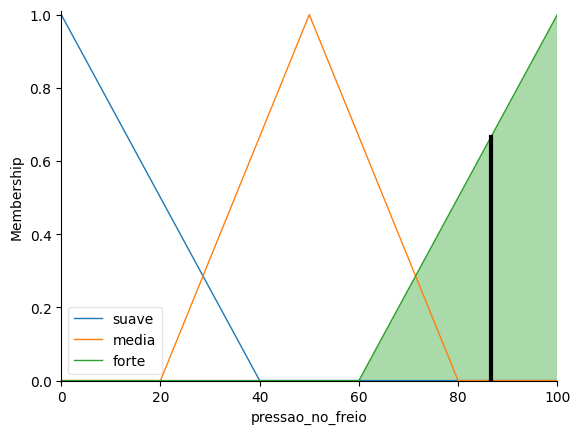

In [52]:
pressao_no_freio.view(sim=freio_controle)
print(freio_controle.output['pressao_no_freio'])